# SisFall Fall Detection using ESP32 + ICM-20948

This notebook develops the software pipeline for wearable fall detection
using the SisFall dataset.

The target is binary classification:

- Fall
- Non-Fall / Activity of Daily Living (ADL)

In [1]:
# ============================================================
# 1. Environment and Dataset Path
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project paths
PROJECT_ROOT = Path(r"C:\Users\vatsa\Parkinson_Project")

DATA_ROOT = PROJECT_ROOT / "data" / "sisfall" / "SisFall_dataset"
RESULTS_ROOT = PROJECT_ROOT / "results" / "fall_detection"

RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Dataset path :", DATA_ROOT)
print("Dataset exists:", DATA_ROOT.exists())
print("Results path :", RESULTS_ROOT)

Project root : C:\Users\vatsa\Parkinson_Project
Dataset path : C:\Users\vatsa\Parkinson_Project\data\sisfall\SisFall_dataset
Dataset exists: True
Results path : C:\Users\vatsa\Parkinson_Project\results\fall_detection


In [2]:
# ============================================================
# 2. Read Dataset Documentation
# ============================================================

README_PATH = DATA_ROOT / "Readme.txt"

print("README exists:", README_PATH.exists())
print("=" * 70)

with open(README_PATH, "r", encoding="utf-8", errors="ignore") as f:
    readme_text = f.read()

print(readme_text[:12000])

README exists: True

731/5000
һǴADXL345Xϲõļٶݡ
ڶǴADXL345Yϲõļٶݡ
ǴADXL345Zϲõļٶݡ

4ɴITG3200Xתݡ
5ɴITG3200Yתݡ
ɴITG3200Zתݡ

ǴMMA8451QXϲõļٶݡ
ڰǴMMA8451QYϲõļٶݡ
9ǴMMA8451QZϲõļٶݡ

1st column is the acceleration data in the X axis measured by the sensor ADXL345.
2nd column is the acceleration data in the Y axis measured by the sensor ADXL345.
3rd column is the acceleration data in the Z axis measured by the sensor ADXL345.

4th column is the rotation data in the X axis measured by the sensor ITG3200.
5th column is the rotation data in the Y axis measured by the sensor ITG3200.
6th column is the rotation data in the Z axis measured by the sensor ITG3200.

7th column is the acceleration data in the X axis measured by the sensor MMA8451Q.
8th column is the acceleration data in the Y axis measured by the sensor MMA8451Q.
9th column is the acceleration data in the Z axis measured by the sensor MMA8451Q.


---- SisFall: A Fall and Movement Dataset ----

Created by:
A. Sucerquia, J.D. Lpez, J.F. Vargas-Bo

## 2. SisFall Dataset Understanding

In [4]:
# ============================================================
# Load and inspect one ADL file and one Fall file
# ============================================================

def load_sisfall_file(file_path):
    """
    Load one raw SisFall recording.

    Each row contains 9 sensor values:
    - ADXL345 acceleration: X, Y, Z
    - ITG3200 angular velocity: X, Y, Z
    - MMA8451Q acceleration: X, Y, Z
    """

    rows = []

    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            # Remove SisFall row formatting: { ... };
            line = line.strip("{};")

            values = [int(value.strip()) for value in line.split(",")]

            if len(values) != 9:
                raise ValueError(
                    f"Expected 9 values, found {len(values)} in {file_path.name}"
                )

            rows.append(values)

    return np.array(rows, dtype=np.float64)


# Example files
adl_file = DATA_ROOT / "SA01" / "D01_SA01_R01.txt"
fall_file = DATA_ROOT / "SA01" / "F01_SA01_R01.txt"

adl_data = load_sisfall_file(adl_file)
fall_data = load_sisfall_file(fall_file)

print("ADL file :", adl_file.name)
print("ADL shape:", adl_data.shape)

print("\nFall file :", fall_file.name)
print("Fall shape:", fall_data.shape)

print("\nFirst 3 rows of ADL data:")
print(adl_data[:3])

print("\nFirst 3 rows of Fall data:")
print(fall_data[:3])

ADL file : D01_SA01_R01.txt
ADL shape: (19999, 9)

Fall file : F01_SA01_R01.txt
Fall shape: (3000, 9)

First 3 rows of ADL data:
[[  17. -179.  -99.  -18. -504. -352.   76. -697. -279.]
 [  15. -174.  -90.  -53. -568. -306.   48. -675. -254.]
 [   1. -176.  -81.  -84. -613. -271.   -2. -668. -221.]]

First 3 rows of Fall data:
[[-9.000e+00 -2.570e+02 -2.500e+01  8.400e+01  2.470e+02  2.700e+01
  -1.200e+02 -9.870e+02  6.300e+01]
 [-3.000e+00 -2.630e+02 -2.300e+01  9.900e+01  2.580e+02  3.500e+01
  -1.100e+02 -1.016e+03  6.800e+01]
 [-1.000e+00 -2.700e+02 -2.200e+01  1.140e+02  2.720e+02  4.500e+01
  -9.400e+01 -1.037e+03  6.900e+01]]


In [5]:
# ============================================================
# Convert selected SisFall sensors to physical units
# ============================================================

# SisFall sensor configuration
ADXL345_RANGE = 16       # ±16 g
ADXL345_RESOLUTION = 13  # bits

ITG3200_RANGE = 2000       # ±2000 °/s
ITG3200_RESOLUTION = 16    # bits

# Conversion factors from the SisFall documentation
ADXL345_SCALE = (
    2 * ADXL345_RANGE
) / (2 ** ADXL345_RESOLUTION)

ITG3200_SCALE = (
    2 * ITG3200_RANGE
) / (2 ** ITG3200_RESOLUTION)

print("ADXL345 scale:", ADXL345_SCALE, "g/bit")
print("ITG3200 scale:", ITG3200_SCALE, "°/s per bit")


def convert_sisfall_data(raw_data):
    """
    Convert the first accelerometer (ADXL345)
    and gyroscope (ITG3200) channels.

    Output channels:
    Ax, Ay, Az  -> acceleration in g
    Gx, Gy, Gz  -> angular velocity in °/s
    """

    converted = np.empty((raw_data.shape[0], 6), dtype=np.float64)

    # ADXL345 acceleration: columns 0-2
    converted[:, 0:3] = raw_data[:, 0:3] * ADXL345_SCALE

    # ITG3200 angular velocity: columns 3-5
    converted[:, 3:6] = raw_data[:, 3:6] * ITG3200_SCALE

    return converted


adl_converted = convert_sisfall_data(adl_data)
fall_converted = convert_sisfall_data(fall_data)

columns = ["Ax", "Ay", "Az", "Gx", "Gy", "Gz"]

adl_df = pd.DataFrame(adl_converted, columns=columns)
fall_df = pd.DataFrame(fall_converted, columns=columns)

print("\nADL converted data:")
print(adl_df.head())

print("\nFall converted data:")
print(fall_df.head())

ADXL345 scale: 0.00390625 g/bit
ITG3200 scale: 0.06103515625 °/s per bit

ADL converted data:
         Ax        Ay        Az        Gx         Gy         Gz
0  0.066406 -0.699219 -0.386719 -1.098633 -30.761719 -21.484375
1  0.058594 -0.679688 -0.351562 -3.234863 -34.667969 -18.676758
2  0.003906 -0.687500 -0.316406 -5.126953 -37.414551 -16.540527
3 -0.039062 -0.703125 -0.300781 -6.347656 -39.489746 -13.854980
4 -0.082031 -0.746094 -0.246094 -7.812500 -41.198730 -11.657715

Fall converted data:
         Ax        Ay        Az        Gx         Gy        Gz
0 -0.035156 -1.003906 -0.097656  5.126953  15.075684  1.647949
1 -0.011719 -1.027344 -0.089844  6.042480  15.747070  2.136230
2 -0.003906 -1.054688 -0.085938  6.958008  16.601562  2.746582
3  0.003906 -1.082031 -0.093750  7.751465  17.456055  3.479004
4  0.007812 -1.097656 -0.097656  8.178711  18.493652  4.272461


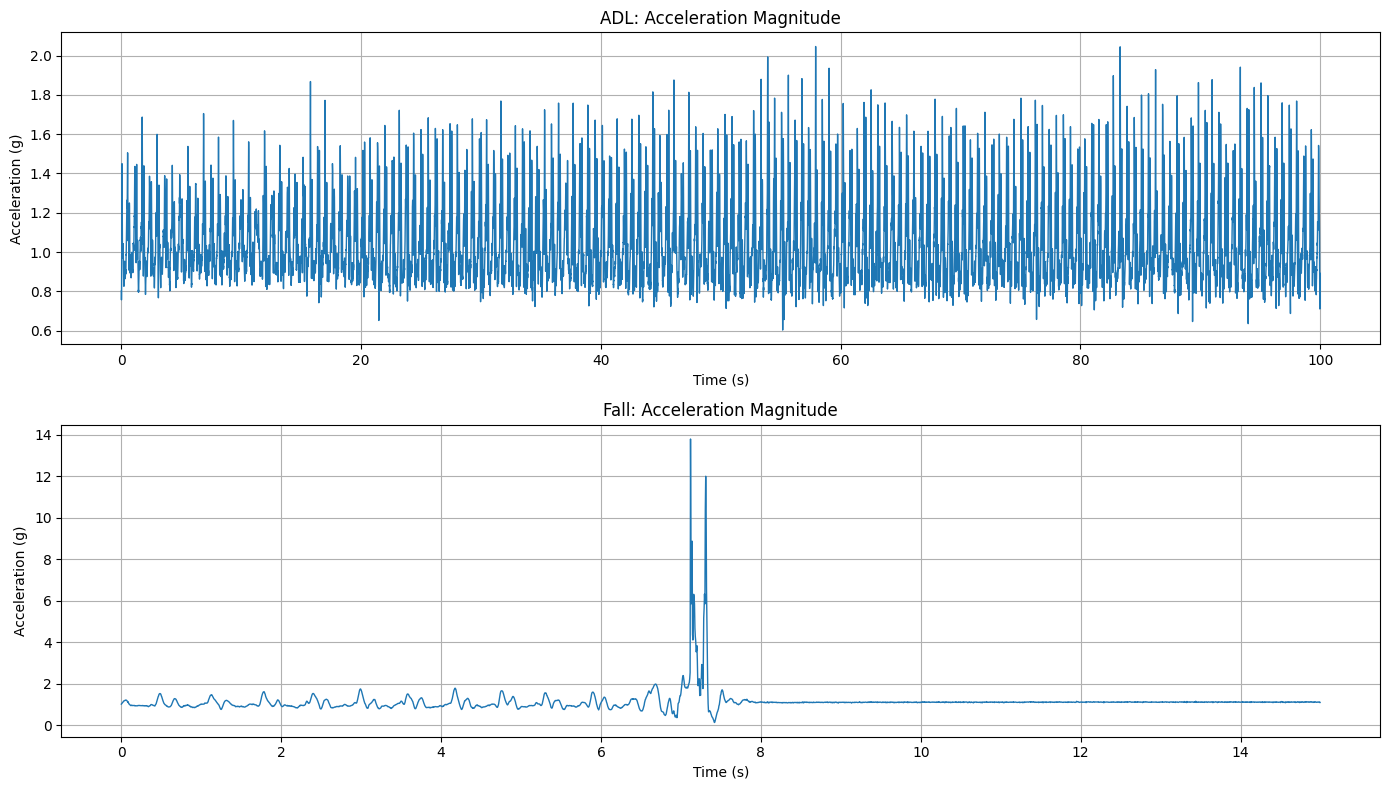

In [6]:
# ============================================================
# Visualize acceleration and angular velocity
# ============================================================

SAMPLE_RATE = 200  # SisFall sampling frequency

# Create time axes
adl_time = np.arange(len(adl_df)) / SAMPLE_RATE
fall_time = np.arange(len(fall_df)) / SAMPLE_RATE

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Acceleration magnitude
adl_acc_mag = np.sqrt(
    adl_df["Ax"]**2 +
    adl_df["Ay"]**2 +
    adl_df["Az"]**2
)

fall_acc_mag = np.sqrt(
    fall_df["Ax"]**2 +
    fall_df["Ay"]**2 +
    fall_df["Az"]**2
)

axes[0].plot(adl_time, adl_acc_mag, linewidth=1)
axes[0].set_title("ADL: Acceleration Magnitude")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Acceleration (g)")
axes[0].grid(True)

axes[1].plot(fall_time, fall_acc_mag, linewidth=1)
axes[1].set_title("Fall: Acceleration Magnitude")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Acceleration (g)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

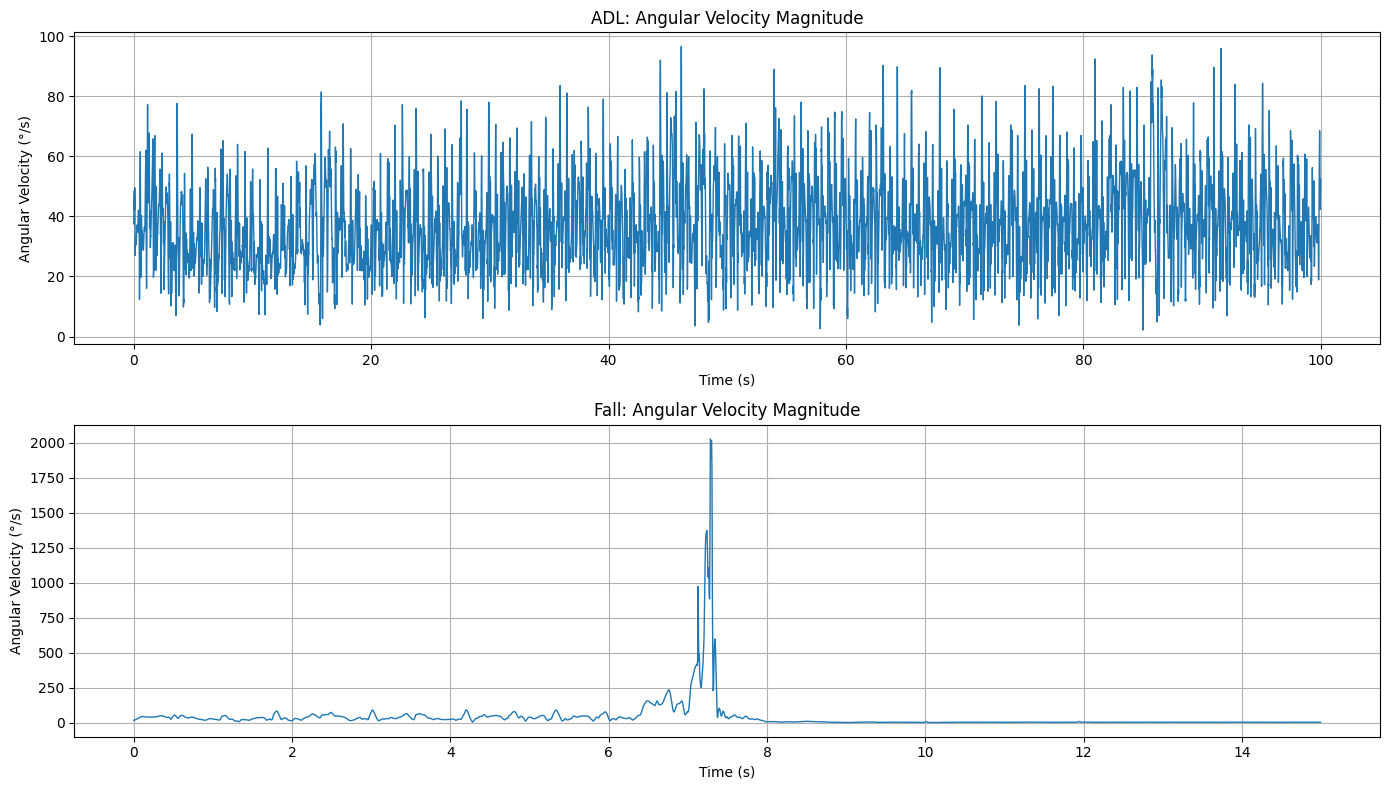

In [7]:
# ============================================================
# Visualize angular velocity magnitude
# ============================================================

adl_gyro_mag = np.sqrt(
    adl_df["Gx"]**2 +
    adl_df["Gy"]**2 +
    adl_df["Gz"]**2
)

fall_gyro_mag = np.sqrt(
    fall_df["Gx"]**2 +
    fall_df["Gy"]**2 +
    fall_df["Gz"]**2
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ADL
axes[0].plot(adl_time, adl_gyro_mag, linewidth=1)
axes[0].set_title("ADL: Angular Velocity Magnitude")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Angular Velocity (°/s)")
axes[0].grid(True)

# Fall
axes[1].plot(fall_time, fall_gyro_mag, linewidth=1)
axes[1].set_title("Fall: Angular Velocity Magnitude")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Angular Velocity (°/s)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 2.1 Recording Labels and Channel Selection

In [8]:
# ============================================================
# Build recording metadata and assign binary labels
# ============================================================

import re

SISFALL_CHANNELS = ["Ax", "Ay", "Az", "Gx", "Gy", "Gz"]

records = []

pattern = re.compile(
    r"^(D\d{2}|F\d{2})_(SA\d{2}|SE\d{2})_(R\d{2})\.txt$",
    re.IGNORECASE
)

for file_path in DATA_ROOT.rglob("*.txt"):
    match = pattern.match(file_path.name)

    if match is None:
        continue

    activity_code = match.group(1).upper()
    subject_id = match.group(2).upper()
    trial_id = match.group(3).upper()

    label = 1 if activity_code.startswith("F") else 0
    label_name = "Fall" if label == 1 else "ADL"

    records.append({
        "file_path": file_path,
        "activity_code": activity_code,
        "subject_id": subject_id,
        "trial_id": trial_id,
        "label": label,
        "label_name": label_name
    })

records_df = pd.DataFrame(records)

records_df = records_df.sort_values(
    ["subject_id", "activity_code", "trial_id"]
).reset_index(drop=True)

print("Total recordings:", len(records_df))
print("\nClass distribution:")
print(records_df["label_name"].value_counts())

print("\nUnique subjects:", records_df["subject_id"].nunique())

print("\nFirst 10 recordings:")
display(records_df.head(10))

Total recordings: 4505

Class distribution:
label_name
ADL     2707
Fall    1798
Name: count, dtype: int64

Unique subjects: 38

First 10 recordings:


,file_path,activity_code,subject_id,trial_id,label,label_name
0,C:\Users\vatsa\Parkinson_Project\data\sisfall\...,D01,SA01,R01,0,ADL
1,C:\Users\vatsa\Parkinson_Project\data\sisfall\...,D02,SA01,R01,0,ADL
2,C:\Users\vatsa\Parkinson_Project\data\sisfall\...,D03,SA01,R01,0,ADL
3,C:\Users\vatsa\Parkinson_Project\data\sisfall\...,D04,SA01,R01,0,ADL
4,C:\Users\vatsa\Parkinson_Project\data\sisfall\...,D05,SA01,R01,0,ADL
5,C:\Users\vatsa\Parkinson_Project\data\sisfall\...,D05,SA01,R02,0,ADL
6,C:\Users\vatsa\Parkinson_Project\data\sisfall\...,D05,SA01,R03,0,ADL
7,C:\Users\vatsa\Parkinson_Project\data\sisfall\...,D05,SA01,R04,0,ADL
8,C:\Users\vatsa\Parkinson_Project\data\sisfall\...,D05,SA01,R05,0,ADL
9,C:\Users\vatsa\Parkinson_Project\data\sisfall\...,D06,SA01,R01,0,ADL


## 3. Subject-Disjoint Data Split

To avoid data leakage, recordings from the same subject must not appear in
both training and test sets.

The split is performed at the subject level before windowing.

In [9]:
# ============================================================
# Subject-disjoint train / validation / test split
# ============================================================

from sklearn.model_selection import train_test_split

# Unique subjects
subjects = sorted(records_df["subject_id"].unique())

# First split: 70% train, 30% temporary
train_subjects, temp_subjects = train_test_split(
    subjects,
    test_size=0.30,
    random_state=42
)

# Second split: divide temporary set equally
val_subjects, test_subjects = train_test_split(
    temp_subjects,
    test_size=0.50,
    random_state=42
)

# Convert to sets for easy membership checking
train_subjects = set(train_subjects)
val_subjects = set(val_subjects)
test_subjects = set(test_subjects)

# Assign each recording to a split
def assign_split(subject_id):
    if subject_id in train_subjects:
        return "train"
    elif subject_id in val_subjects:
        return "validation"
    else:
        return "test"


records_df["split"] = records_df["subject_id"].apply(assign_split)

print("Subjects:")
print("Train      :", len(train_subjects), sorted(train_subjects))
print("Validation :", len(val_subjects), sorted(val_subjects))
print("Test       :", len(test_subjects), sorted(test_subjects))

print("\nRecording counts:")
print(records_df["split"].value_counts())

print("\nClass distribution by split:")
print(
    pd.crosstab(
        records_df["split"],
        records_df["label_name"]
    )
)

print("\nSubject overlap check:")
print(
    "Train ∩ Validation:",
    train_subjects.intersection(val_subjects)
)
print(
    "Train ∩ Test:",
    train_subjects.intersection(test_subjects)
)
print(
    "Validation ∩ Test:",
    val_subjects.intersection(test_subjects)
)

Subjects:
Train      : 26 ['SA01', 'SA02', 'SA03', 'SA04', 'SA06', 'SA08', 'SA10', 'SA11', 'SA12', 'SA13', 'SA15', 'SA17', 'SA19', 'SA20', 'SA21', 'SA22', 'SA23', 'SE01', 'SE03', 'SE06', 'SE07', 'SE09', 'SE10', 'SE12', 'SE13', 'SE15']
Validation : 6 ['SA07', 'SA09', 'SA14', 'SE05', 'SE08', 'SE14']
Test       : 6 ['SA05', 'SA16', 'SA18', 'SE02', 'SE04', 'SE11']

Recording counts:
split
train         3238
validation     639
test           628
Name: count, dtype: int64

Class distribution by split:
label_name   ADL  Fall
split                 
test         403   225
train       1890  1348
validation   414   225

Subject overlap check:
Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


## 4. Windowing and Signal Preparation

In [10]:
# ============================================================
# Windowing configuration
# ============================================================

SAMPLE_RATE = 200

WINDOW_SECONDS = 2
WINDOW_SIZE = SAMPLE_RATE * WINDOW_SECONDS

OVERLAP = 0.50
STEP_SIZE = int(WINDOW_SIZE * (1 - OVERLAP))

print("Sampling rate :", SAMPLE_RATE, "Hz")
print("Window length :", WINDOW_SECONDS, "seconds")
print("Samples/window:", WINDOW_SIZE)
print("Overlap       :", OVERLAP * 100, "%")
print("Step size     :", STEP_SIZE, "samples")

Sampling rate : 200 Hz
Window length : 2 seconds
Samples/window: 400
Overlap       : 50.0 %
Step size     : 200 samples


In [11]:
# ============================================================
# Create overlapping windows
# ============================================================

def create_windows(data, window_size=WINDOW_SIZE, step_size=STEP_SIZE):
    """
    Split a sensor recording into overlapping fixed-size windows.

    Parameters
    ----------
    data : np.ndarray
        Shape: (samples, channels)

    Returns
    -------
    windows : np.ndarray
        Shape: (number_of_windows, window_size, channels)
    """

    windows = []

    for start in range(0, len(data) - window_size + 1, step_size):
        end = start + window_size
        windows.append(data[start:end])

    if not windows:
        return np.empty((0, window_size, data.shape[1]))

    return np.stack(windows)


# Test on the two recordings we already loaded
adl_windows = create_windows(adl_converted)
fall_windows = create_windows(fall_converted)

print("ADL windows shape :", adl_windows.shape)
print("Fall windows shape:", fall_windows.shape)

ADL windows shape : (98, 400, 6)
Fall windows shape: (14, 400, 6)


In [12]:
# ============================================================
# Verify one window
# ============================================================

print("One ADL window shape:", adl_windows[0].shape)

print("\nExpected:")
print("(400, 6)")

print("\nChannels:")
print(SISFALL_CHANNELS)

print("\nFirst 3 samples of first ADL window:")
print(adl_windows[0][:3])

One ADL window shape: (400, 6)

Expected:
(400, 6)

Channels:
['Ax', 'Ay', 'Az', 'Gx', 'Gy', 'Gz']

First 3 samples of first ADL window:
[[ 6.64062500e-02 -6.99218750e-01 -3.86718750e-01 -1.09863281e+00
  -3.07617188e+01 -2.14843750e+01]
 [ 5.85937500e-02 -6.79687500e-01 -3.51562500e-01 -3.23486328e+00
  -3.46679688e+01 -1.86767578e+01]
 [ 3.90625000e-03 -6.87500000e-01 -3.16406250e-01 -5.12695312e+00
  -3.74145508e+01 -1.65405273e+01]]


## 5. Fall Event Localization and Window Labels

In [13]:
# ============================================================
# Calculate acceleration and angular velocity magnitudes
# ============================================================

def calculate_magnitudes(sensor_data):
    """
    Calculate acceleration and angular velocity magnitudes.

    Input:
        sensor_data shape = (samples, 6)

    Channels:
        Ax, Ay, Az, Gx, Gy, Gz
    """

    acceleration_magnitude = np.sqrt(
        sensor_data[:, 0]**2 +
        sensor_data[:, 1]**2 +
        sensor_data[:, 2]**2
    )

    angular_velocity_magnitude = np.sqrt(
        sensor_data[:, 3]**2 +
        sensor_data[:, 4]**2 +
        sensor_data[:, 5]**2
    )

    return acceleration_magnitude, angular_velocity_magnitude


adl_acc_mag, adl_gyro_mag = calculate_magnitudes(adl_converted)
fall_acc_mag, fall_gyro_mag = calculate_magnitudes(fall_converted)

print("ADL acceleration magnitude shape :", adl_acc_mag.shape)
print("ADL angular velocity shape       :", adl_gyro_mag.shape)

print("Fall acceleration magnitude shape:", fall_acc_mag.shape)
print("Fall angular velocity shape      :", fall_gyro_mag.shape)

ADL acceleration magnitude shape : (19999,)
ADL angular velocity shape       : (19999,)
Fall acceleration magnitude shape: (3000,)
Fall angular velocity shape      : (3000,)


In [14]:
# ============================================================
# Locate the strongest candidate fall event
# ============================================================

# Normalize the two signals so one does not dominate
acc_score = (
    fall_acc_mag - np.mean(fall_acc_mag)
) / np.std(fall_acc_mag)

gyro_score = (
    fall_gyro_mag - np.mean(fall_gyro_mag)
) / np.std(fall_gyro_mag)

combined_score = acc_score + gyro_score

peak_index = np.argmax(combined_score)
peak_time = peak_index / SAMPLE_RATE

print("Candidate fall-event sample:", peak_index)
print(f"Candidate fall-event time: {peak_time:.2f} seconds")
print(f"Acceleration at event: {fall_acc_mag[peak_index]:.2f} g")
print(
    f"Angular velocity at event: "
    f"{fall_gyro_mag[peak_index]:.2f} °/s"
)

Candidate fall-event sample: 1461
Candidate fall-event time: 7.30 seconds
Acceleration at event: 10.38 g
Angular velocity at event: 1813.82 °/s


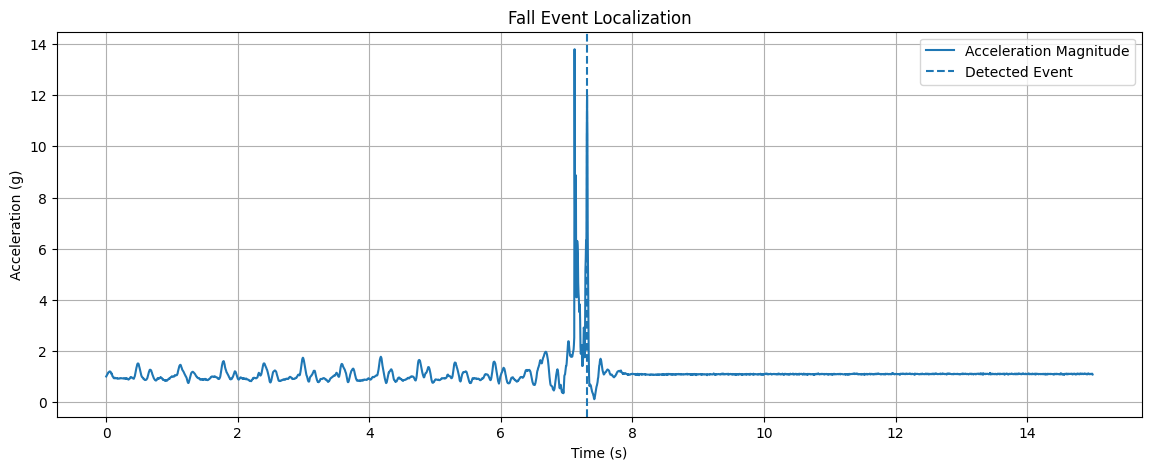

In [15]:
# ============================================================
# Visualize the localized fall event
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    fall_time,
    fall_acc_mag,
    label="Acceleration Magnitude"
)

plt.axvline(
    peak_time,
    linestyle="--",
    label="Detected Event"
)

plt.title("Fall Event Localization")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.grid(True)
plt.legend()

plt.show()

In [16]:
# ============================================================
# Extract an event-centered window
# ============================================================

def extract_event_window(
    sensor_data,
    event_index,
    window_size=WINDOW_SIZE
):
    """
    Extract a fixed-size window centered approximately
    on the detected event.
    """

    half_window = window_size // 2

    start = event_index - half_window
    end = start + window_size

    # Shift window if it extends beyond recording boundaries
    if start < 0:
        start = 0
        end = window_size

    if end > len(sensor_data):
        end = len(sensor_data)
        start = end - window_size

    if start < 0 or end > len(sensor_data):
        raise ValueError("Recording is shorter than the requested window.")

    return sensor_data[start:end]


fall_event_window = extract_event_window(
    fall_converted,
    peak_index
)

print("Fall event window shape:", fall_event_window.shape)

event_start = (peak_index - WINDOW_SIZE // 2) / SAMPLE_RATE
event_end = (
    peak_index + WINDOW_SIZE // 2
) / SAMPLE_RATE

print(f"Approximate window: {event_start:.2f} s → {event_end:.2f} s")

Fall event window shape: (400, 6)
Approximate window: 6.30 s → 8.30 s


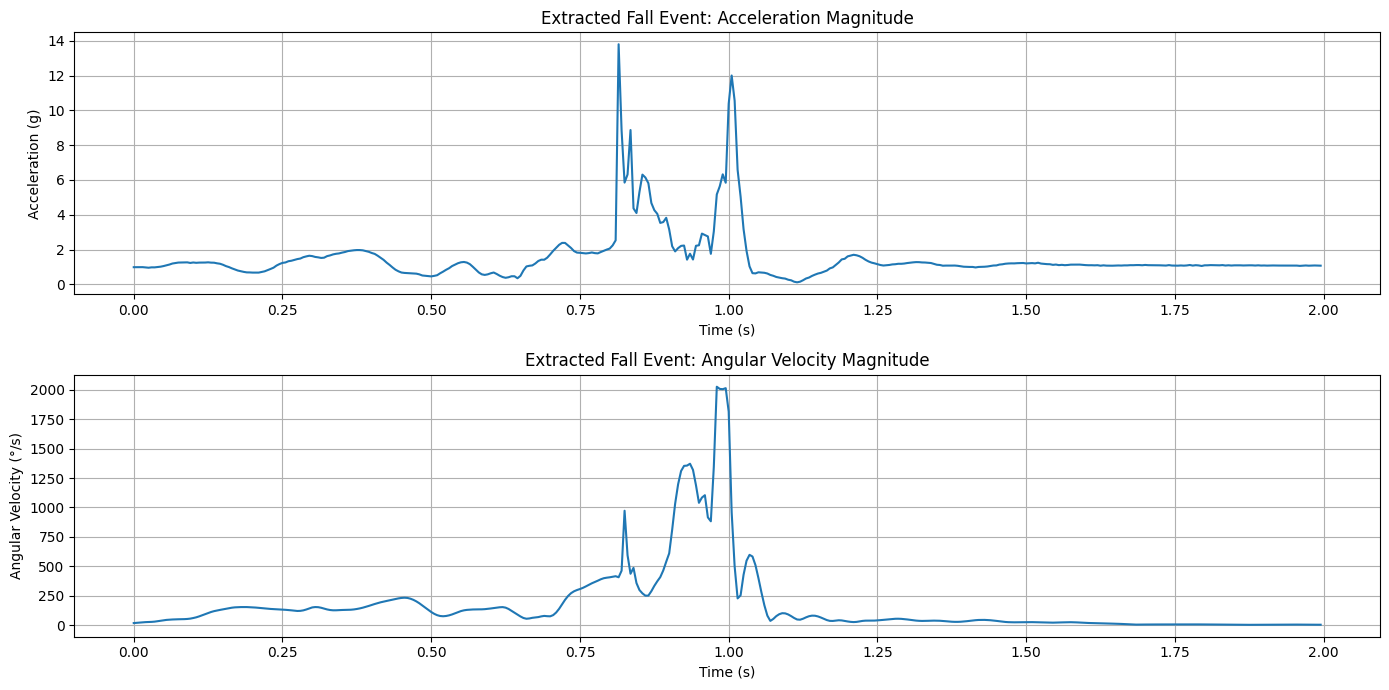

In [17]:
# ============================================================
# Visualize extracted fall-event window
# ============================================================

window_time = np.arange(WINDOW_SIZE) / SAMPLE_RATE

window_acc_mag, window_gyro_mag = calculate_magnitudes(
    fall_event_window
)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(window_time, window_acc_mag)
axes[0].set_title("Extracted Fall Event: Acceleration Magnitude")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Acceleration (g)")
axes[0].grid(True)

axes[1].plot(window_time, window_gyro_mag)
axes[1].set_title("Extracted Fall Event: Angular Velocity Magnitude")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Angular Velocity (°/s)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 5. Fall Event Localization and Window Labels

In [18]:
# ============================================================
# Process one SisFall recording
# ============================================================

def process_recording(file_path, label):
    """
    Load one SisFall recording, convert the required six channels,
    and create 2-second windows.

    ADL:
        All available overlapping windows are returned.

    Fall:
        One event-centered window is returned based on the
        strongest combined acceleration + angular velocity event.

    Returns
    -------
    windows : np.ndarray
        Shape: (n_windows, 400, 6)

    labels : np.ndarray
        Shape: (n_windows,)
    """

    # Load raw data
    raw_data = load_sisfall_file(file_path)

    # Convert first accelerometer + gyroscope
    sensor_data = convert_sisfall_data(raw_data)

    # --------------------------------------------------------
    # ADL / Non-Fall
    # --------------------------------------------------------
    if label == 0:

        windows = create_windows(
            sensor_data,
            window_size=WINDOW_SIZE,
            step_size=STEP_SIZE
        )

        labels = np.zeros(len(windows), dtype=np.int8)

        return windows, labels

    # --------------------------------------------------------
    # Fall
    # --------------------------------------------------------
    acceleration_mag, gyro_mag = calculate_magnitudes(sensor_data)

    # Standardize each magnitude signal
    acc_std = np.std(acceleration_mag)
    gyro_std = np.std(gyro_mag)

    if acc_std == 0 or gyro_std == 0:
        raise ValueError(
            f"Zero standard deviation found in {file_path.name}"
        )

    acc_score = (
        acceleration_mag - np.mean(acceleration_mag)
    ) / acc_std

    gyro_score = (
        gyro_mag - np.mean(gyro_mag)
    ) / gyro_std

    combined_score = acc_score + gyro_score

    # Strongest candidate fall event
    event_index = np.argmax(combined_score)

    # Extract event-centered window
    event_window = extract_event_window(
        sensor_data,
        event_index,
        window_size=WINDOW_SIZE
    )

    windows = event_window[np.newaxis, :, :]
    labels = np.array([1], dtype=np.int8)

    return windows, labels

In [19]:
# ============================================================
# Test the complete recording processor
# ============================================================

adl_test_windows, adl_test_labels = process_recording(
    adl_file,
    label=0
)

fall_test_windows, fall_test_labels = process_recording(
    fall_file,
    label=1
)

print("ADL:")
print("  Windows:", adl_test_windows.shape)
print("  Labels :", adl_test_labels)

print("\nFall:")
print("  Windows:", fall_test_windows.shape)
print("  Labels :", fall_test_labels)

ADL:
  Windows: (98, 400, 6)
  Labels : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Fall:
  Windows: (1, 400, 6)
  Labels : [1]


## 6. Feature Extraction

In [20]:
# ============================================================
# Feature extraction from a 2-second sensor window
# ============================================================

FEATURE_STATS = [
    "mean",
    "std",
    "min",
    "max",
    "range",
    "rms",
    "median",
    "energy"
]


def extract_channel_features(signal, prefix):
    """
    Extract statistical features from one sensor channel.
    """

    signal = np.asarray(signal, dtype=np.float64)

    return {
        f"{prefix}_mean": np.mean(signal),
        f"{prefix}_std": np.std(signal),
        f"{prefix}_min": np.min(signal),
        f"{prefix}_max": np.max(signal),
        f"{prefix}_range": np.max(signal) - np.min(signal),
        f"{prefix}_rms": np.sqrt(np.mean(signal ** 2)),
        f"{prefix}_median": np.median(signal),
        f"{prefix}_energy": np.sum(signal ** 2),
    }


def extract_window_features(window):
    """
    Extract features from one window.

    Input shape:
        (400, 6)

    Channels:
        Ax, Ay, Az, Gx, Gy, Gz
    """

    features = {}

    # Individual sensor channels
    for i, channel in enumerate(SISFALL_CHANNELS):
        features.update(
            extract_channel_features(
                window[:, i],
                channel
            )
        )

    # Magnitude signals
    acc_mag = np.sqrt(
        window[:, 0] ** 2 +
        window[:, 1] ** 2 +
        window[:, 2] ** 2
    )

    gyro_mag = np.sqrt(
        window[:, 3] ** 2 +
        window[:, 4] ** 2 +
        window[:, 5] ** 2
    )

    features.update(
        extract_channel_features(
            acc_mag,
            "AccMag"
        )
    )

    features.update(
        extract_channel_features(
            gyro_mag,
            "GyroMag"
        )
    )

    return features

In [21]:
# ============================================================
# Test feature extraction
# ============================================================

sample_features = extract_window_features(
    fall_event_window
)

sample_features_df = pd.DataFrame([sample_features])

print("Number of extracted features:", len(sample_features))
print("\nFeature names:")
print(sample_features_df.columns.tolist())

print("\nFirst 10 feature values:")
display(sample_features_df.iloc[:, :10])

Number of extracted features: 64

Feature names:
['Ax_mean', 'Ax_std', 'Ax_min', 'Ax_max', 'Ax_range', 'Ax_rms', 'Ax_median', 'Ax_energy', 'Ay_mean', 'Ay_std', 'Ay_min', 'Ay_max', 'Ay_range', 'Ay_rms', 'Ay_median', 'Ay_energy', 'Az_mean', 'Az_std', 'Az_min', 'Az_max', 'Az_range', 'Az_rms', 'Az_median', 'Az_energy', 'Gx_mean', 'Gx_std', 'Gx_min', 'Gx_max', 'Gx_range', 'Gx_rms', 'Gx_median', 'Gx_energy', 'Gy_mean', 'Gy_std', 'Gy_min', 'Gy_max', 'Gy_range', 'Gy_rms', 'Gy_median', 'Gy_energy', 'Gz_mean', 'Gz_std', 'Gz_min', 'Gz_max', 'Gz_range', 'Gz_rms', 'Gz_median', 'Gz_energy', 'AccMag_mean', 'AccMag_std', 'AccMag_min', 'AccMag_max', 'AccMag_range', 'AccMag_rms', 'AccMag_median', 'AccMag_energy', 'GyroMag_mean', 'GyroMag_std', 'GyroMag_min', 'GyroMag_max', 'GyroMag_range', 'GyroMag_rms', 'GyroMag_median', 'GyroMag_energy']

First 10 feature values:


,Ax_mean,Ax_std,Ax_min,Ax_max,Ax_range,Ax_rms,Ax_median,Ax_energy,Ay_mean,Ay_std
0,-0.461875,0.805303,-4.363281,4.523438,8.886719,0.928354,-0.552734,344.736572,0.130713,1.412159


In [23]:
# ============================================================
# Process a complete split into feature vectors
# ============================================================

def build_feature_dataset(
    records,
    max_adl_windows=None,
    random_state=42
):
    """
    Process recordings and return a feature-level DataFrame.

    Parameters
    ----------
    records : pd.DataFrame
        Recording metadata for one split.

    max_adl_windows : int or None
        Maximum number of ADL windows to retain.
        Falls are retained completely.

    random_state : int
        Reproducibility seed.

    Returns
    -------
    feature_df : pd.DataFrame
        Feature vectors plus metadata.
    """

    rng = np.random.default_rng(random_state)

    feature_rows = []

    for idx, row in records.iterrows():

        windows, labels = process_recording(
            row["file_path"],
            row["label"]
        )

        for window, label in zip(windows, labels):

            features = extract_window_features(window)

            features["subject_id"] = row["subject_id"]
            features["activity_code"] = row["activity_code"]
            features["trial_id"] = row["trial_id"]
            features["label"] = int(label)
            features["label_name"] = (
                "Fall" if label == 1 else "ADL"
            )

            feature_rows.append(features)

    feature_df = pd.DataFrame(feature_rows)

    # --------------------------------------------------------
    # Optional ADL balancing
    # --------------------------------------------------------
    if max_adl_windows is not None:

        adl_df = feature_df[
            feature_df["label"] == 0
        ]

        fall_df = feature_df[
            feature_df["label"] == 1
        ]

        if len(adl_df) > max_adl_windows:

            selected_indices = rng.choice(
                adl_df.index.to_numpy(),
                size=max_adl_windows,
                replace=False
            )

            adl_df = adl_df.loc[selected_indices]

        feature_df = pd.concat(
            [adl_df, fall_df],
            ignore_index=True
        )

    # Shuffle
    feature_df = feature_df.sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

    return feature_df

In [24]:
# ============================================================
# Build training feature dataset
# ============================================================

train_records = records_df[
    records_df["split"] == "train"
].copy()

train_fall_count = train_records[
    train_records["label"] == 1
].shape[0]

print("Training recordings:", len(train_records))
print("Training fall recordings:", train_fall_count)

print("\nProcessing training recordings...")

Training recordings: 3238
Training fall recordings: 1348

Processing training recordings...


In [25]:
train_features = build_feature_dataset(
    train_records,
    max_adl_windows=train_fall_count,
    random_state=42
)

print("\nTraining feature dataset shape:")
print(train_features.shape)

print("\nTraining class distribution:")
print(train_features["label_name"].value_counts())

print("\nNumber of numeric features:")
print(
    len([
        c for c in train_features.columns
        if c not in [
            "subject_id",
            "activity_code",
            "trial_id",
            "label",
            "label_name"
        ]
    ])
)

display(train_features.head())


Training feature dataset shape:
(2696, 69)

Training class distribution:
label_name
ADL     1348
Fall    1348
Name: count, dtype: int64

Number of numeric features:
64


,Ax_mean,Ax_std,Ax_min,Ax_max,Ax_range,Ax_rms,Ax_median,Ax_energy,Ay_mean,Ay_std,...,GyroMag_max,GyroMag_range,GyroMag_rms,GyroMag_median,GyroMag_energy,subject_id,activity_code,trial_id,label,label_name
0,0.066270,0.011825,0.039062,0.128906,0.089844,0.067316,0.066406,1.812592,-0.967236,0.017991,...,30.799842,29.817574,8.926793,6.524724,3.187506e+04,SA22,D08,R03,0,ADL
1,0.007051,0.560820,-1.191406,1.738281,2.929688,0.560865,0.000000,125.827637,-0.951562,0.956138,...,188.971546,174.891198,77.108972,71.235790,2.378317e+06,SA21,D04,R01,0,ADL
2,0.374961,0.357244,-0.273438,1.597656,1.871094,0.517899,0.578125,107.287628,0.350938,0.591356,...,296.461526,292.603738,113.474108,49.442349,5.150549e+06,SE06,F08,R03,1,Fall
3,-0.048496,0.216114,-0.992188,0.683594,1.675781,0.221488,-0.031250,19.622803,0.142129,0.715401,...,242.247343,238.380392,80.201496,49.289966,2.572912e+06,SA19,F13,R05,1,Fall
4,-0.025977,0.337216,-1.074219,1.023438,2.097656,0.338215,0.005859,45.755829,-0.999355,0.583527,...,183.710639,169.754260,71.975439,63.795012,2.072186e+06,SA23,D03,R01,0,ADL


## 7. Validation and Test Feature Sets

In [26]:
# ============================================================
# Build validation and test feature datasets
# ============================================================

validation_records = records_df[
    records_df["split"] == "validation"
].copy()

test_records = records_df[
    records_df["split"] == "test"
].copy()

validation_fall_count = validation_records[
    validation_records["label"] == 1
].shape[0]

print("Validation recordings:", len(validation_records))
print("Validation fall recordings:", validation_fall_count)

print("\nProcessing validation recordings...")

validation_features = build_feature_dataset(
    validation_records,
    max_adl_windows=validation_fall_count,
    random_state=42
)

print("\nValidation feature dataset shape:")
print(validation_features.shape)

print("\nValidation class distribution:")
print(validation_features["label_name"].value_counts())


print("\n" + "=" * 60)
print("Test recordings:", len(test_records))
print("Processing test recordings...")

test_features = build_feature_dataset(
    test_records,
    max_adl_windows=None,
    random_state=42
)

print("\nTest feature dataset shape:")
print(test_features.shape)

print("\nTest class distribution:")
print(test_features["label_name"].value_counts())

Validation recordings: 639
Validation fall recordings: 225

Processing validation recordings...

Validation feature dataset shape:
(450, 69)

Validation class distribution:
label_name
Fall    225
ADL     225
Name: count, dtype: int64

Test recordings: 628
Processing test recordings...

Test feature dataset shape:
(7543, 69)

Test class distribution:
label_name
ADL     7318
Fall     225
Name: count, dtype: int64


In [27]:
# ============================================================
# Create balanced test set for fair evaluation
# ============================================================

test_fall = test_features[
    test_features["label"] == 1
].copy()

test_adl = test_features[
    test_features["label"] == 0
].copy()

# Match the number of ADL windows to fall windows
test_adl_balanced = test_adl.sample(
    n=len(test_fall),
    random_state=42
)

test_balanced = pd.concat(
    [test_adl_balanced, test_fall],
    ignore_index=True
)

test_balanced = test_balanced.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Natural test set:")
print(test_features["label_name"].value_counts())

print("\nBalanced test set:")
print(test_balanced["label_name"].value_counts())

print("\nBalanced test shape:")
print(test_balanced.shape)

Natural test set:
label_name
ADL     7318
Fall     225
Name: count, dtype: int64

Balanced test set:
label_name
Fall    225
ADL     225
Name: count, dtype: int64

Balanced test shape:
(450, 69)


## 8. Model Training and Evaluation

In [28]:
# ============================================================
# Prepare feature matrices and labels
# ============================================================

META_COLUMNS = [
    "subject_id",
    "activity_code",
    "trial_id",
    "label",
    "label_name"
]

FEATURE_COLUMNS = [
    column
    for column in train_features.columns
    if column not in META_COLUMNS
]

X_train = train_features[FEATURE_COLUMNS]
y_train = train_features["label"]

X_val = validation_features[FEATURE_COLUMNS]
y_val = validation_features["label"]

X_test = test_balanced[FEATURE_COLUMNS]
y_test = test_balanced["label"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val  :", X_val.shape)
print("y_val  :", y_val.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("\nClasses:")
print("0 = ADL / Non-Fall")
print("1 = Fall")

X_train: (2696, 64)
y_train: (2696,)
X_val  : (450, 64)
y_val  : (450,)
X_test : (450, 64)
y_test : (450,)

Classes:
0 = ADL / Non-Fall
1 = Fall


In [29]:
# ============================================================
# Random Forest Fall Detector
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

rf_model.fit(X_train, y_train)

print("Training complete.")

# Validation prediction
y_val_pred_rf = rf_model.predict(X_val)

val_accuracy_rf = accuracy_score(
    y_val,
    y_val_pred_rf
)

print(f"\nValidation Accuracy: {val_accuracy_rf * 100:.2f}%")

print("\nValidation Classification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_rf,
        target_names=["ADL", "Fall"],
        digits=4
    )
)

Training Random Forest...
Training complete.

Validation Accuracy: 99.56%

Validation Classification Report:
              precision    recall  f1-score   support

         ADL     1.0000    0.9911    0.9955       225
        Fall     0.9912    1.0000    0.9956       225

    accuracy                         0.9956       450
   macro avg     0.9956    0.9956    0.9956       450
weighted avg     0.9956    0.9956    0.9956       450



Test Accuracy: 99.78%

Test Classification Report:
              precision    recall  f1-score   support

         ADL     1.0000    0.9956    0.9978       225
        Fall     0.9956    1.0000    0.9978       225

    accuracy                         0.9978       450
   macro avg     0.9978    0.9978    0.9978       450
weighted avg     0.9978    0.9978    0.9978       450


Confusion Matrix:
[[224   1]
 [  0 225]]


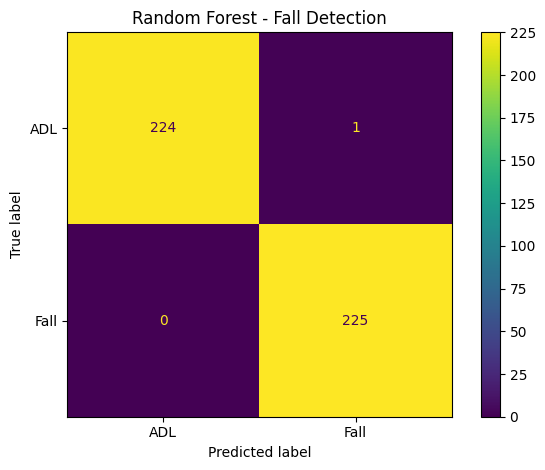

In [30]:
# ============================================================
# Random Forest Test Evaluation
# ============================================================

y_test_pred_rf = rf_model.predict(X_test)

test_accuracy_rf = accuracy_score(
    y_test,
    y_test_pred_rf
)

print(f"Test Accuracy: {test_accuracy_rf * 100:.2f}%")

print("\nTest Classification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_rf,
        target_names=["ADL", "Fall"],
        digits=4
    )
)

cm_rf = confusion_matrix(
    y_test,
    y_test_pred_rf
)

print("\nConfusion Matrix:")
print(cm_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["ADL", "Fall"]
)

disp.plot()
plt.title("Random Forest - Fall Detection")
plt.tight_layout()
plt.show()

## 8.2 Support Vector Machine

In [32]:
# ============================================================
# SVM with Standard Scaling
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "svm",
        SVC(
            kernel="rbf",
            C=10,
            gamma="scale"
        )
    )
])

print("Training SVM...")

svm_model.fit(X_train, y_train)

print("Training complete.")

# Validation
y_val_pred_svm = svm_model.predict(X_val)

val_accuracy_svm = accuracy_score(
    y_val,
    y_val_pred_svm
)

print(f"\nValidation Accuracy: {val_accuracy_svm * 100:.2f}%")

print("\nValidation Classification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_svm,
        target_names=["ADL", "Fall"],
        digits=4
    )
)

Training SVM...
Training complete.

Validation Accuracy: 99.33%

Validation Classification Report:
              precision    recall  f1-score   support

         ADL     1.0000    0.9867    0.9933       225
        Fall     0.9868    1.0000    0.9934       225

    accuracy                         0.9933       450
   macro avg     0.9934    0.9933    0.9933       450
weighted avg     0.9934    0.9933    0.9933       450



Test Accuracy: 99.78%

Test Classification Report:
              precision    recall  f1-score   support

         ADL     1.0000    0.9956    0.9978       225
        Fall     0.9956    1.0000    0.9978       225

    accuracy                         0.9978       450
   macro avg     0.9978    0.9978    0.9978       450
weighted avg     0.9978    0.9978    0.9978       450


Confusion Matrix:
[[224   1]
 [  0 225]]


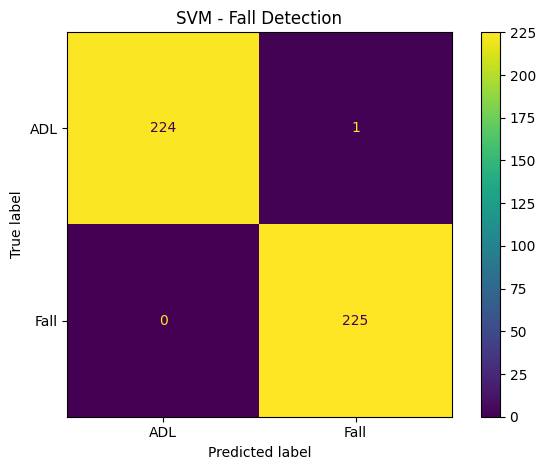

In [33]:
# ============================================================
# SVM Test Evaluation
# ============================================================

y_test_pred_svm = svm_model.predict(X_test)

test_accuracy_svm = accuracy_score(
    y_test,
    y_test_pred_svm
)

print(f"Test Accuracy: {test_accuracy_svm * 100:.2f}%")

print("\nTest Classification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_svm,
        target_names=["ADL", "Fall"],
        digits=4
    )
)

cm_svm = confusion_matrix(
    y_test,
    y_test_pred_svm
)

print("\nConfusion Matrix:")
print(cm_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["ADL", "Fall"]
)

disp.plot()
plt.title("SVM - Fall Detection")
plt.tight_layout()
plt.show()

### 8.3 Natural Test Evaluation

In [34]:
# ============================================================
# Evaluate both models on the natural test distribution
# ============================================================

X_test_natural = test_features[FEATURE_COLUMNS]
y_test_natural = test_features["label"]

# Random Forest
y_test_natural_pred_rf = rf_model.predict(X_test_natural)

print("=" * 60)
print("RANDOM FOREST - NATURAL TEST")
print("=" * 60)

print(
    classification_report(
        y_test_natural,
        y_test_natural_pred_rf,
        target_names=["ADL", "Fall"],
        digits=4
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test_natural,
        y_test_natural_pred_rf
    )
)


# SVM
y_test_natural_pred_svm = svm_model.predict(X_test_natural)

print("\n" + "=" * 60)
print("SVM - NATURAL TEST")
print("=" * 60)

print(
    classification_report(
        y_test_natural,
        y_test_natural_pred_svm,
        target_names=["ADL", "Fall"],
        digits=4
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test_natural,
        y_test_natural_pred_svm
    )
)

RANDOM FOREST - NATURAL TEST
              precision    recall  f1-score   support

         ADL     1.0000    0.9992    0.9996      7318
        Fall     0.9740    1.0000    0.9868       225

    accuracy                         0.9992      7543
   macro avg     0.9870    0.9996    0.9932      7543
weighted avg     0.9992    0.9992    0.9992      7543

Confusion Matrix:
[[7312    6]
 [   0  225]]

SVM - NATURAL TEST
              precision    recall  f1-score   support

         ADL     1.0000    0.9941    0.9971      7318
        Fall     0.8396    1.0000    0.9128       225

    accuracy                         0.9943      7543
   macro avg     0.9198    0.9971    0.9549      7543
weighted avg     0.9952    0.9943    0.9945      7543

Confusion Matrix:
[[7275   43]
 [   0  225]]


## 9. Real-Time Fall Detection Logic

In [35]:
# ============================================================
# Derive initial fall-detection thresholds from training ADLs
# ============================================================

train_adl = train_features[
    train_features["label"] == 0
].copy()

train_fall = train_features[
    train_features["label"] == 1
].copy()

print("Training ADL windows :", len(train_adl))
print("Training Fall windows:", len(train_fall))

# Thresholds based only on ADL training data
ACC_THRESHOLD = train_adl["AccMag_max"].quantile(0.99)
GYRO_THRESHOLD = train_adl["GyroMag_max"].quantile(0.99)

print(f"\nAcceleration threshold : {ACC_THRESHOLD:.2f} g")
print(f"Angular velocity threshold: {GYRO_THRESHOLD:.2f} °/s")

Training ADL windows : 1348
Training Fall windows: 1348

Acceleration threshold : 6.06 g
Angular velocity threshold: 421.42 °/s


              precision    recall  f1-score   support

         ADL     0.5685    0.9778    0.7190       225
        Fall     0.9206    0.2578    0.4028       225

    accuracy                         0.6178       450
   macro avg     0.7446    0.6178    0.5609       450
weighted avg     0.7446    0.6178    0.5609       450

Confusion Matrix:
[[220   5]
 [167  58]]


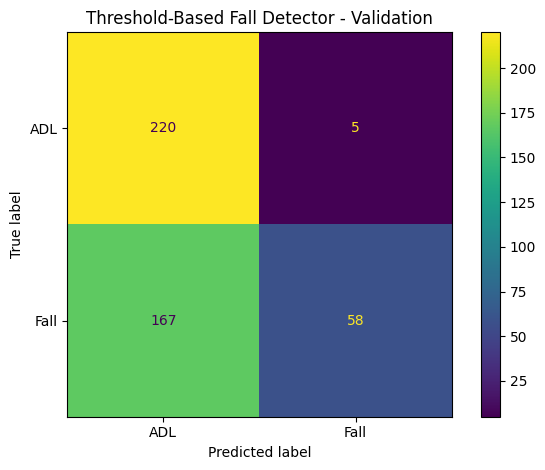

In [36]:
# ============================================================
# Evaluate threshold-based fall detection on validation data
# ============================================================

def threshold_detector(feature_df):
    """
    Basic real-time-compatible fall detector.

    A window is flagged as a possible fall when
    both acceleration and angular velocity exceed
    their respective thresholds.
    """

    return (
        (feature_df["AccMag_max"] >= ACC_THRESHOLD) &
        (feature_df["GyroMag_max"] >= GYRO_THRESHOLD)
    ).astype(int)


y_val_pred_threshold = threshold_detector(validation_features)

print(
    classification_report(
        validation_features["label"],
        y_val_pred_threshold,
        target_names=["ADL", "Fall"],
        digits=4
    )
)

cm_threshold = confusion_matrix(
    validation_features["label"],
    y_val_pred_threshold
)

print("Confusion Matrix:")
print(cm_threshold)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_threshold,
    display_labels=["ADL", "Fall"]
)

disp.plot()
plt.title("Threshold-Based Fall Detector - Validation")
plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# Compare individual and OR-based threshold detectors
# ============================================================

val_acc = validation_features["AccMag_max"]
val_gyro = validation_features["GyroMag_max"]
val_true = validation_features["label"]

# Acceleration-only detector
pred_acc_only = (
    val_acc >= ACC_THRESHOLD
).astype(int)

# Gyroscope-only detector
pred_gyro_only = (
    val_gyro >= GYRO_THRESHOLD
).astype(int)

# OR detector
pred_or = (
    (val_acc >= ACC_THRESHOLD) |
    (val_gyro >= GYRO_THRESHOLD)
).astype(int)

print("Acceleration-only detector")
print(
    classification_report(
        val_true,
        pred_acc_only,
        target_names=["ADL", "Fall"],
        digits=4
    )
)

print("=" * 60)

print("Gyroscope-only detector")
print(
    classification_report(
        val_true,
        pred_gyro_only,
        target_names=["ADL", "Fall"],
        digits=4
    )
)

print("=" * 60)

print("OR detector")
print(
    classification_report(
        val_true,
        pred_or,
        target_names=["ADL", "Fall"],
        digits=4
    )
)

print("OR Confusion Matrix:")
print(confusion_matrix(val_true, pred_or))

Acceleration-only detector
              precision    recall  f1-score   support

         ADL     0.6414    0.9778    0.7746       225
        Fall     0.9533    0.4533    0.6145       225

    accuracy                         0.7156       450
   macro avg     0.7973    0.7156    0.6946       450
weighted avg     0.7973    0.7156    0.6946       450

Gyroscope-only detector
              precision    recall  f1-score   support

         ADL     0.5912    0.9511    0.7291       225
        Fall     0.8750    0.3422    0.4920       225

    accuracy                         0.6467       450
   macro avg     0.7331    0.6467    0.6106       450
weighted avg     0.7331    0.6467    0.6106       450

OR detector
              precision    recall  f1-score   support

         ADL     0.6730    0.9511    0.7882       225
        Fall     0.9167    0.5378    0.6779       225

    accuracy                         0.7444       450
   macro avg     0.7948    0.7444    0.7330       450
weighted av

## 9.1 Validation-Based Threshold Selection

In [38]:
# ============================================================
# Search threshold combinations on the validation set
# ============================================================

from sklearn.metrics import confusion_matrix

val_acc_max = validation_features["AccMag_max"].to_numpy()
val_gyro_max = validation_features["GyroMag_max"].to_numpy()
val_labels = validation_features["label"].to_numpy()

# Candidate thresholds
acc_thresholds = np.percentile(
    train_adl["AccMag_max"],
    [90, 92, 94, 96, 97, 98, 99]
)

gyro_thresholds = np.percentile(
    train_adl["GyroMag_max"],
    [90, 92, 94, 96, 97, 98, 99]
)

results = []

for acc_threshold in acc_thresholds:
    for gyro_threshold in gyro_thresholds:

        # OR rule
        predictions = (
            (val_acc_max >= acc_threshold) |
            (val_gyro_max >= gyro_threshold)
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            val_labels,
            predictions,
            labels=[0, 1]
        ).ravel()

        fall_recall = tp / (tp + fn)
        false_alarm_rate = fp / (fp + tn)

        results.append({
            "acc_threshold": acc_threshold,
            "gyro_threshold": gyro_threshold,
            "fall_recall": fall_recall,
            "false_alarm_rate": false_alarm_rate,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn
        })

threshold_results = pd.DataFrame(results)

print("Total threshold combinations tested:",
      len(threshold_results))

display(
    threshold_results.sort_values(
        ["fall_recall", "false_alarm_rate"],
        ascending=[False, True]
    ).head(15)
)

Total threshold combinations tested: 49


,acc_threshold,gyro_threshold,fall_recall,false_alarm_rate,tp,fp,fn,tn
1,3.487690,235.473538,0.986667,0.164444,222,37,3,188
0,3.487690,217.940894,0.986667,0.168889,222,38,3,187
8,3.705473,235.473538,0.982222,0.151111,221,34,4,191
7,3.705473,217.940894,0.982222,0.160000,221,36,4,189
15,4.039778,235.473538,0.973333,0.146667,219,33,6,192
14,4.039778,217.940894,0.973333,0.160000,219,36,6,189
2,3.487690,258.088560,0.964444,0.151111,217,34,8,191
3,3.487690,282.941642,0.960000,0.151111,216,34,9,191
9,3.705473,258.088560,0.955556,0.128889,215,29,10,196
21,4.482333,217.940894,0.955556,0.155556,215,35,10,190


In [39]:
# ============================================================
# Show threshold combinations with high fall recall
# ============================================================

high_recall_results = threshold_results[
    threshold_results["fall_recall"] >= 0.80
].copy()

high_recall_results = high_recall_results.sort_values(
    ["false_alarm_rate", "fall_recall"],
    ascending=[True, False]
)

print(
    "Threshold combinations achieving at least 80% fall recall:",
    len(high_recall_results)
)

display(high_recall_results.head(15))

Threshold combinations achieving at least 80% fall recall: 40


,acc_threshold,gyro_threshold,fall_recall,false_alarm_rate,tp,fp,fn,tn
20,4.039778,421.421583,0.840000,0.084444,189,19,36,206
19,4.039778,352.791342,0.853333,0.088889,192,20,33,205
32,4.736878,302.084702,0.826667,0.093333,186,21,39,204
39,5.106079,302.084702,0.808889,0.093333,182,21,43,204
25,4.482333,302.084702,0.844444,0.097778,190,22,35,203
45,6.059854,282.941642,0.800000,0.097778,180,22,45,203
18,4.039778,302.084702,0.902222,0.102222,203,23,22,202
31,4.736878,282.941642,0.871111,0.102222,196,23,29,202
38,5.106079,282.941642,0.853333,0.102222,192,23,33,202
24,4.482333,282.941642,0.884444,0.106667,199,24,26,201


In [40]:
# ============================================================
# Select candidate thresholds using an explicit requirement
# ============================================================

threshold_results["fall_f1"] = (
    2 * threshold_results["tp"]
    /
    (
        2 * threshold_results["tp"]
        + threshold_results["fp"]
        + threshold_results["fn"]
    )
)

# Initial engineering requirement:
# Detect at least 90% of fall events.
candidates = threshold_results[
    threshold_results["fall_recall"] >= 0.90
].copy()

# Among those candidates, show the lowest false-alarm rates first.
candidates = candidates.sort_values(
    ["false_alarm_rate", "fall_recall"],
    ascending=[True, False]
)

print("Candidates with fall recall >= 90%:")
display(candidates.head(15))

Candidates with fall recall >= 90%:


,acc_threshold,gyro_threshold,fall_recall,false_alarm_rate,tp,fp,fn,tn,fall_f1
18,4.039778,302.084702,0.902222,0.102222,203,23,22,202,0.900222
17,4.039778,282.941642,0.924444,0.111111,208,25,17,200,0.908297
12,3.705473,352.791342,0.902222,0.111111,203,25,22,200,0.896247
11,3.705473,302.084702,0.928889,0.115556,209,26,16,199,0.908696
23,4.482333,258.088560,0.906667,0.115556,204,26,21,199,0.896703
16,4.039778,258.088560,0.937778,0.120000,211,27,14,198,0.911447
10,3.705473,282.941642,0.946667,0.124444,213,28,12,197,0.914163
9,3.705473,258.088560,0.955556,0.128889,215,29,10,196,0.916844
43,6.059854,235.473538,0.924444,0.133333,208,30,17,195,0.898488
29,4.736878,235.473538,0.946667,0.137778,213,31,12,194,0.908316


In [41]:
# ============================================================
# Set the initial real-time detector thresholds
# ============================================================

selected_threshold = candidates.iloc[0]

REALTIME_ACC_THRESHOLD = selected_threshold["acc_threshold"]
REALTIME_GYRO_THRESHOLD = selected_threshold["gyro_threshold"]

print("Initial real-time thresholds")
print(
    f"Acceleration : {REALTIME_ACC_THRESHOLD:.2f} g"
)
print(
    f"Angular velocity : {REALTIME_GYRO_THRESHOLD:.2f} °/s"
)

print("\nValidation characteristics:")
print(
    f"Fall recall : "
    f"{selected_threshold['fall_recall'] * 100:.2f}%"
)

print(
    f"False-alarm rate : "
    f"{selected_threshold['false_alarm_rate'] * 100:.2f}%"
)

print(
    f"Fall F1 : "
    f"{selected_threshold['fall_f1'] * 100:.2f}%"
)

Initial real-time thresholds
Acceleration : 4.04 g
Angular velocity : 302.08 °/s

Validation characteristics:
Fall recall : 90.22%
False-alarm rate : 10.22%
Fall F1 : 90.02%


In [42]:
# ============================================================
# Evaluate frozen real-time thresholds on unseen test subjects
# ============================================================

def evaluate_threshold_detector(feature_df, dataset_name):
    """
    Evaluate the frozen threshold detector on a dataset.
    """

    predictions = (
        (feature_df["AccMag_max"] >= REALTIME_ACC_THRESHOLD) |
        (feature_df["GyroMag_max"] >= REALTIME_GYRO_THRESHOLD)
    ).astype(int)

    true_labels = feature_df["label"]

    tn, fp, fn, tp = confusion_matrix(
        true_labels,
        predictions,
        labels=[0, 1]
    ).ravel()

    fall_recall = tp / (tp + fn) if (tp + fn) else 0
    false_alarm_rate = fp / (fp + tn) if (fp + tn) else 0

    print("=" * 60)
    print(dataset_name)
    print("=" * 60)

    print(
        classification_report(
            true_labels,
            predictions,
            target_names=["ADL", "Fall"],
            digits=4
        )
    )

    print("Confusion Matrix:")
    print(
        np.array([
            [tn, fp],
            [fn, tp]
        ])
    )

    print(f"\nFall recall      : {fall_recall * 100:.2f}%")
    print(f"False-alarm rate : {false_alarm_rate * 100:.2f}%")

    return predictions


# Balanced test evaluation
test_balanced_pred_threshold = evaluate_threshold_detector(
    test_balanced,
    "BALANCED TEST"
)

# Natural test evaluation
test_natural_pred_threshold = evaluate_threshold_detector(
    test_features,
    "NATURAL TEST"
)

BALANCED TEST
              precision    recall  f1-score   support

         ADL     0.9484    0.8978    0.9224       225
        Fall     0.9030    0.9511    0.9264       225

    accuracy                         0.9244       450
   macro avg     0.9257    0.9244    0.9244       450
weighted avg     0.9257    0.9244    0.9244       450

Confusion Matrix:
[[202  23]
 [ 11 214]]

Fall recall      : 95.11%
False-alarm rate : 10.22%
NATURAL TEST
              precision    recall  f1-score   support

         ADL     0.9983    0.8948    0.9437      7318
        Fall     0.2175    0.9511    0.3540       225

    accuracy                         0.8965      7543
   macro avg     0.6079    0.9229    0.6489      7543
weighted avg     0.9750    0.8965    0.9261      7543

Confusion Matrix:
[[6548  770]
 [  11  214]]

Fall recall      : 95.11%
False-alarm rate : 10.52%


In [43]:
# ============================================================
# Combined acceleration + angular velocity fall score
# ============================================================

# Training-derived reference thresholds
ACC_REFERENCE = REALTIME_ACC_THRESHOLD
GYRO_REFERENCE = REALTIME_GYRO_THRESHOLD

print(f"Acceleration reference: {ACC_REFERENCE:.2f} g")
print(f"Gyroscope reference   : {GYRO_REFERENCE:.2f} °/s")


def calculate_fall_score(feature_df):
    """
    Calculate a combined fall score using the maximum
    acceleration and angular velocity in each window.

    A score above 1.0 means the combined signal strength
    exceeds the reference operating point.
    """

    acc_ratio = (
        feature_df["AccMag_max"] / ACC_REFERENCE
    )

    gyro_ratio = (
        feature_df["GyroMag_max"] / GYRO_REFERENCE
    )

    # Equal weighting for the initial prototype
    fall_score = (
        0.5 * acc_ratio +
        0.5 * gyro_ratio
    )

    return fall_score


val_fall_scores = calculate_fall_score(
    validation_features
)

print("Validation score statistics:")
print(val_fall_scores.describe())

Acceleration reference: 4.04 g
Gyroscope reference   : 302.08 °/s
Validation score statistics:
count    450.000000
mean       0.955172
std        0.723192
min        0.124884
25%        0.289770
50%        0.900458
75%        1.410472
max        3.724489
dtype: float64


In [44]:
# ============================================================
# Search combined-score thresholds on validation data
# ============================================================

score_thresholds = np.arange(
    0.8,
    3.01,
    0.05
)

score_results = []

val_true = validation_features["label"].to_numpy()

for threshold in score_thresholds:

    predictions = (
        val_fall_scores.to_numpy() >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        val_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    fall_recall = tp / (tp + fn)
    false_alarm_rate = fp / (fp + tn)

    precision = tp / (tp + fp) if (tp + fp) else 0

    f1 = (
        2 * precision * fall_recall /
        (precision + fall_recall)
        if (precision + fall_recall)
        else 0
    )

    score_results.append({
        "score_threshold": threshold,
        "fall_recall": fall_recall,
        "false_alarm_rate": false_alarm_rate,
        "precision": precision,
        "f1": f1,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn
    })


score_results_df = pd.DataFrame(score_results)

# Keep candidates with at least 90% fall recall
score_candidates = score_results_df[
    score_results_df["fall_recall"] >= 0.90
].sort_values(
    ["false_alarm_rate", "fall_recall"],
    ascending=[True, False]
)

print("Combined-score candidates with Fall Recall >= 90%:")
display(score_candidates.head(15))

Combined-score candidates with Fall Recall >= 90%:


,score_threshold,fall_recall,false_alarm_rate,precision,f1,tp,fp,fn,tn
1,0.85,0.92,0.133333,0.873418,0.896104,207,30,18,195
0,0.80,0.96,0.146667,0.867470,0.911392,216,33,9,192


In [45]:
# ============================================================
# Select initial combined-score threshold
# ============================================================

selected_score = score_candidates.iloc[0]

COMBINED_SCORE_THRESHOLD = selected_score[
    "score_threshold"
]

print(
    f"Selected score threshold: "
    f"{COMBINED_SCORE_THRESHOLD:.2f}"
)

print(
    f"Validation Fall Recall: "
    f"{selected_score['fall_recall'] * 100:.2f}%"
)

print(
    f"Validation False-Alarm Rate: "
    f"{selected_score['false_alarm_rate'] * 100:.2f}%"
)

print(
    f"Validation Fall F1: "
    f"{selected_score['f1'] * 100:.2f}%"
)

Selected score threshold: 0.85
Validation Fall Recall: 92.00%
Validation False-Alarm Rate: 13.33%
Validation Fall F1: 89.61%


In [46]:
# ============================================================
# Evaluate frozen combined-score detector on test data
# ============================================================

def evaluate_combined_score(feature_df, dataset_name):
    """
    Evaluate the frozen combined-score detector.
    """

    scores = calculate_fall_score(feature_df)

    predictions = (
        scores >= COMBINED_SCORE_THRESHOLD
    ).astype(int)

    true_labels = feature_df["label"]

    tn, fp, fn, tp = confusion_matrix(
        true_labels,
        predictions,
        labels=[0, 1]
    ).ravel()

    fall_recall = tp / (tp + fn) if (tp + fn) else 0
    false_alarm_rate = fp / (fp + tn) if (fp + tn) else 0

    print("=" * 60)
    print(dataset_name)
    print("=" * 60)

    print(
        classification_report(
            true_labels,
            predictions,
            target_names=["ADL", "Fall"],
            digits=4
        )
    )

    print("Confusion Matrix:")
    print(
        np.array([
            [tn, fp],
            [fn, tp]
        ])
    )

    print(f"\nFall recall      : {fall_recall * 100:.2f}%")
    print(f"False-alarm rate : {false_alarm_rate * 100:.2f}%")

    return predictions


# Balanced test
test_balanced_pred_score = evaluate_combined_score(
    test_balanced,
    "BALANCED TEST"
)

# Natural test
test_natural_pred_score = evaluate_combined_score(
    test_features,
    "NATURAL TEST"
)

BALANCED TEST
              precision    recall  f1-score   support

         ADL     0.9476    0.8844    0.9149       225
        Fall     0.8917    0.9511    0.9204       225

    accuracy                         0.9178       450
   macro avg     0.9196    0.9178    0.9177       450
weighted avg     0.9196    0.9178    0.9177       450

Confusion Matrix:
[[199  26]
 [ 11 214]]

Fall recall      : 95.11%
False-alarm rate : 11.56%
NATURAL TEST
              precision    recall  f1-score   support

         ADL     0.9983    0.8858    0.9387      7318
        Fall     0.2038    0.9511    0.3357       225

    accuracy                         0.8877      7543
   macro avg     0.6011    0.9184    0.6372      7543
weighted avg     0.9746    0.8877    0.9207      7543

Confusion Matrix:
[[6482  836]
 [  11  214]]

Fall recall      : 95.11%
False-alarm rate : 11.42%


## 9.2 Temporal Persistence for Real-Time Detection

In [47]:
# ============================================================
# Temporal persistence detector
# ============================================================

PERSISTENCE_WINDOWS = 2

def apply_temporal_persistence(predictions, required_windows=2):
    """
    Confirm a fall only when the detector is active
    for the required number of consecutive windows.

    Parameters
    ----------
    predictions : array-like
        Binary predictions in chronological order.

    required_windows : int
        Number of consecutive positive windows required.

    Returns
    -------
    confirmed : np.ndarray
        Binary confirmed fall predictions.
    """

    predictions = np.asarray(predictions, dtype=int)
    confirmed = np.zeros_like(predictions)

    consecutive = 0

    for i, prediction in enumerate(predictions):

        if prediction == 1:
            consecutive += 1

            if consecutive >= required_windows:
                confirmed[i] = 1
        else:
            consecutive = 0

    return confirmed

In [48]:
# ============================================================
# Build chronological windows for one complete recording
# ============================================================

def build_chronological_features(file_path):
    """
    Load one complete recording and create chronological
    2-second overlapping windows with extracted features.

    No shuffling is performed.
    """

    raw_data = load_sisfall_file(file_path)

    sensor_data = convert_sisfall_data(raw_data)

    windows = create_windows(
        sensor_data,
        window_size=WINDOW_SIZE,
        step_size=STEP_SIZE
    )

    feature_rows = []

    for window_index, window in enumerate(windows):

        features = extract_window_features(window)

        features["window_index"] = window_index
        features["start_time"] = (
            window_index * STEP_SIZE / SAMPLE_RATE
        )
        features["end_time"] = (
            window_index * STEP_SIZE + WINDOW_SIZE
        ) / SAMPLE_RATE

        feature_rows.append(features)

    return pd.DataFrame(feature_rows)

In [49]:
# ============================================================
# Verify chronological processing on the example fall
# ============================================================

fall_chronological = build_chronological_features(
    fall_file
)

print("Number of chronological windows:",
      len(fall_chronological))

print("\nFirst windows:")
display(
    fall_chronological[
        [
            "window_index",
            "start_time",
            "end_time",
            "AccMag_max",
            "GyroMag_max"
        ]
    ].head()
)

Number of chronological windows: 14

First windows:


,window_index,start_time,end_time,AccMag_max,GyroMag_max
0,0,0.0,2.0,1.610403,82.633780
1,1,1.0,3.0,1.741706,82.633780
2,2,2.0,4.0,1.741706,89.775101
3,3,3.0,5.0,1.779836,90.748461
4,4,4.0,6.0,1.779836,90.748461


In [50]:
# ============================================================
# Apply the frozen OR threshold detector chronologically
# ============================================================

def chronological_threshold_predictions(feature_df):
    """
    Apply the frozen acceleration OR gyroscope threshold
    to chronologically ordered windows.
    """

    predictions = (
        (feature_df["AccMag_max"] >= REALTIME_ACC_THRESHOLD) |
        (feature_df["GyroMag_max"] >= REALTIME_GYRO_THRESHOLD)
    ).astype(int)

    return predictions.to_numpy()

In [51]:
# ============================================================
# Apply temporal persistence
# ============================================================

fall_chronological["raw_prediction"] = (
    chronological_threshold_predictions(
        fall_chronological
    )
)

fall_chronological["confirmed_prediction"] = (
    apply_temporal_persistence(
        fall_chronological["raw_prediction"],
        required_windows=2
    )
)

display(
    fall_chronological[
        [
            "window_index",
            "start_time",
            "end_time",
            "AccMag_max",
            "GyroMag_max",
            "raw_prediction",
            "confirmed_prediction"
        ]
    ]
)

,window_index,start_time,end_time,AccMag_max,GyroMag_max,raw_prediction,confirmed_prediction
0,0,0.0,2.0,1.610403,82.633780,0,0
1,1,1.0,3.0,1.741706,82.633780,0,0
2,2,2.0,4.0,1.741706,89.775101,0,0
3,3,3.0,5.0,1.779836,90.748461,0,0
4,4,4.0,6.0,1.779836,90.748461,0,0
5,5,5.0,7.0,1.974203,233.828073,0,0
6,6,6.0,8.0,13.795916,2025.097009,1,0
7,7,7.0,9.0,13.795916,2025.097009,1,1
8,8,8.0,10.0,1.127371,9.566957,0,0
9,9,9.0,11.0,1.131525,6.471742,0,0


In [52]:
# ============================================================
# Recording-level evaluation with temporal persistence
# ============================================================

def evaluate_recordings_with_persistence(
    records,
    persistence_windows=2
):
    """
    Evaluate the frozen OR threshold detector at the
    recording level using chronological windows.

    A recording is classified as Fall when at least one
    confirmed fall event is detected.
    """

    results = []

    total = len(records)

    for count, (_, row) in enumerate(records.iterrows(), start=1):

        chronological_features = build_chronological_features(
            row["file_path"]
        )

        raw_predictions = chronological_threshold_predictions(
            chronological_features
        )

        confirmed_predictions = apply_temporal_persistence(
            raw_predictions,
            required_windows=persistence_windows
        )

        recording_prediction = int(
            np.any(confirmed_predictions == 1)
        )

        results.append({
            "file_name": row["file_path"].name,
            "subject_id": row["subject_id"],
            "activity_code": row["activity_code"],
            "trial_id": row["trial_id"],
            "true_label": row["label"],
            "true_label_name": row["label_name"],
            "raw_positive_windows": int(
                np.sum(raw_predictions)
            ),
            "confirmed_positive_windows": int(
                np.sum(confirmed_predictions)
            ),
            "recording_prediction": recording_prediction
        })

        if count % 50 == 0 or count == total:
            print(f"Processed {count} / {total} recordings")

    return pd.DataFrame(results)

In [53]:
# ============================================================
# Run recording-level evaluation on unseen test subjects
# ============================================================

test_recording_results = evaluate_recordings_with_persistence(
    test_records,
    persistence_windows=2
)

print("\nEvaluation complete.")
print(
    "Recordings evaluated:",
    len(test_recording_results)
)

display(test_recording_results.head())

Processed 50 / 628 recordings
Processed 100 / 628 recordings
Processed 150 / 628 recordings
Processed 200 / 628 recordings
Processed 250 / 628 recordings
Processed 300 / 628 recordings
Processed 350 / 628 recordings
Processed 400 / 628 recordings
Processed 450 / 628 recordings
Processed 500 / 628 recordings
Processed 550 / 628 recordings
Processed 600 / 628 recordings
Processed 628 / 628 recordings

Evaluation complete.
Recordings evaluated: 628


,file_name,subject_id,activity_code,trial_id,true_label,true_label_name,raw_positive_windows,confirmed_positive_windows,recording_prediction
0,D01_SA05_R01.txt,SA05,D01,R01,0,ADL,0,0,0
1,D02_SA05_R01.txt,SA05,D02,R01,0,ADL,0,0,0
2,D03_SA05_R01.txt,SA05,D03,R01,0,ADL,2,1,1
3,D04_SA05_R01.txt,SA05,D04,R01,0,ADL,99,98,1
4,D05_SA05_R01.txt,SA05,D05,R01,0,ADL,0,0,0


In [54]:
# ============================================================
# Recording-level performance
# ============================================================

recording_true = test_recording_results["true_label"]
recording_pred = test_recording_results["recording_prediction"]

print(
    classification_report(
        recording_true,
        recording_pred,
        target_names=["ADL", "Fall"],
        digits=4
    )
)

recording_cm = confusion_matrix(
    recording_true,
    recording_pred,
    labels=[0, 1]
)

print("Recording-level Confusion Matrix:")
print(recording_cm)

              precision    recall  f1-score   support

         ADL     0.9679    0.8238    0.8901       403
        Fall     0.7509    0.9511    0.8392       225

    accuracy                         0.8694       628
   macro avg     0.8594    0.8875    0.8646       628
weighted avg     0.8902    0.8694    0.8719       628

Recording-level Confusion Matrix:
[[332  71]
 [ 11 214]]


## 9.3 Recovery-Based Fall Confirmation

In [55]:
# ============================================================
# Recovery-based fall confirmation
# ============================================================

def detect_transient_fall(
    predictions,
    minimum_positive_windows=2,
    recovery_windows=1
):
    """
    Confirm a possible fall when:
    
    1. At least `minimum_positive_windows` consecutive
       abnormal windows occur.
    2. They are followed by `recovery_windows`
       consecutive normal windows.

    This is intended as a simple real-time prototype rule.
    """

    predictions = np.asarray(predictions, dtype=int)

    n = len(predictions)

    for start in range(n):

        if predictions[start] != 1:
            continue

        # Count consecutive positive windows
        end = start

        while end < n and predictions[end] == 1:
            end += 1

        positive_count = end - start

        # Minimum abnormal-event duration
        if positive_count < minimum_positive_windows:
            continue

        # Check recovery after abnormal event
        recovery_end = end + recovery_windows

        if recovery_end <= n:
            recovery = predictions[end:recovery_end]

            if np.all(recovery == 0):
                return 1

    return 0

In [56]:
# ============================================================
# Test recovery-based confirmation on example fall
# ============================================================

raw_predictions = chronological_threshold_predictions(
    fall_chronological
)

transient_detection = detect_transient_fall(
    raw_predictions,
    minimum_positive_windows=2,
    recovery_windows=1
)

print("Raw predictions:")
print(raw_predictions)

print("\nRecovery-confirmed fall:", transient_detection)

Raw predictions:
[0 0 0 0 0 0 1 1 0 0 0 0 0 0]

Recovery-confirmed fall: 1


In [57]:
# ============================================================
# Recording-level validation with recovery confirmation
# ============================================================

def evaluate_recovery_rule(
    records,
    minimum_positive_windows=2,
    recovery_windows=1
):
    """
    Evaluate recovery-based confirmation at recording level.
    """

    results = []

    total = len(records)

    for count, (_, row) in enumerate(records.iterrows(), start=1):

        chronological_features = build_chronological_features(
            row["file_path"]
        )

        raw_predictions = chronological_threshold_predictions(
            chronological_features
        )

        recording_prediction = detect_transient_fall(
            raw_predictions,
            minimum_positive_windows=minimum_positive_windows,
            recovery_windows=recovery_windows
        )

        results.append({
            "file_name": row["file_path"].name,
            "subject_id": row["subject_id"],
            "activity_code": row["activity_code"],
            "trial_id": row["trial_id"],
            "true_label": row["label"],
            "recording_prediction": recording_prediction
        })

        if count % 50 == 0 or count == total:
            print(f"Processed {count} / {total} recordings")

    return pd.DataFrame(results)

In [58]:
# ============================================================
# Run recovery-based detector on validation recordings
# ============================================================

validation_recovery_results = evaluate_recovery_rule(
    validation_records,
    minimum_positive_windows=2,
    recovery_windows=1
)

validation_true = validation_recovery_results["true_label"]
validation_pred = validation_recovery_results["recording_prediction"]

print("\nValidation results:")
print(
    classification_report(
        validation_true,
        validation_pred,
        target_names=["ADL", "Fall"],
        digits=4
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        validation_true,
        validation_pred,
        labels=[0, 1]
    )
)

Processed 50 / 639 recordings
Processed 100 / 639 recordings
Processed 150 / 639 recordings
Processed 200 / 639 recordings
Processed 250 / 639 recordings
Processed 300 / 639 recordings
Processed 350 / 639 recordings
Processed 400 / 639 recordings
Processed 450 / 639 recordings
Processed 500 / 639 recordings
Processed 550 / 639 recordings
Processed 600 / 639 recordings
Processed 639 / 639 recordings

Validation results:
              precision    recall  f1-score   support

         ADL     0.9401    0.8333    0.8835       414
        Fall     0.7463    0.9022    0.8169       225

    accuracy                         0.8576       639
   macro avg     0.8432    0.8678    0.8502       639
weighted avg     0.8718    0.8576    0.8600       639

Confusion Matrix:
[[345  69]
 [ 22 203]]


In [59]:
# ============================================================
# Compare temporal persistence lengths on validation recordings
# ============================================================

def collect_validation_predictions(records):
    """
    Process validation recordings once and store the
    chronological raw threshold predictions.
    """

    all_results = []

    total = len(records)

    for count, (_, row) in enumerate(records.iterrows(), start=1):

        chronological_features = build_chronological_features(
            row["file_path"]
        )

        raw_predictions = chronological_threshold_predictions(
            chronological_features
        )

        all_results.append({
            "file_name": row["file_path"].name,
            "subject_id": row["subject_id"],
            "true_label": row["label"],
            "raw_predictions": raw_predictions
        })

        if count % 50 == 0 or count == total:
            print(f"Processed {count} / {total}")

    return all_results


validation_prediction_sequences = collect_validation_predictions(
    validation_records
)

print("\nValidation prediction sequences collected:",
      len(validation_prediction_sequences))

Processed 50 / 639
Processed 100 / 639
Processed 150 / 639
Processed 200 / 639
Processed 250 / 639
Processed 300 / 639
Processed 350 / 639
Processed 400 / 639
Processed 450 / 639
Processed 500 / 639
Processed 550 / 639
Processed 600 / 639
Processed 639 / 639

Validation prediction sequences collected: 639


In [61]:
# ============================================================
# Evaluate different persistence lengths
# ============================================================

persistence_results = []

for persistence_windows in [1, 2, 3]:

    true_labels = []
    predictions = []

    for item in validation_prediction_sequences:

        recording_prediction = detect_transient_fall(
            item["raw_predictions"],
            minimum_positive_windows=persistence_windows,
            recovery_windows=0
        )

        true_labels.append(item["true_label"])
        predictions.append(recording_prediction)

    true_labels = np.array(true_labels)
    predictions = np.array(predictions)

    tn, fp, fn, tp = confusion_matrix(
        true_labels,
        predictions,
        labels=[0, 1]
    ).ravel()

    fall_recall = tp / (tp + fn)
    adl_specificity = tn / (tn + fp)
    false_alarm_rate = fp / (fp + tn)

    persistence_results.append({
        "persistence_windows": persistence_windows,
        "accuracy": accuracy_score(
            true_labels,
            predictions
        ),
        "fall_recall": fall_recall,
        "adl_specificity": adl_specificity,
        "false_alarm_rate": false_alarm_rate,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn
    })


persistence_results_df = pd.DataFrame(
    persistence_results
)

display(persistence_results_df)

,persistence_windows,accuracy,fall_recall,adl_specificity,false_alarm_rate,tp,fp,fn,tn
0,1,0.848200,0.902222,0.818841,0.181159,203,75,22,339
1,2,0.848200,0.902222,0.818841,0.181159,203,75,22,339
2,3,0.641628,0.111111,0.929952,0.070048,25,29,200,385


## 10. Real-Time Streaming Detector Prototype

In [65]:
# ============================================================
# Simulate streaming SisFall data sample-by-sample
# ============================================================

detector = StreamingFallDetector(
    sample_rate=200,
    window_seconds=2,
    overlap=0.50,
    acc_threshold=REALTIME_ACC_THRESHOLD,
    gyro_threshold=REALTIME_GYRO_THRESHOLD,
    persistence_windows=2
)

alert_times = []

for sample_index, sample in enumerate(fall_converted):

    ax, ay, az, gx, gy, gz = sample

    fall_detected = detector.update(
        ax, ay, az,
        gx, gy, gz
    )

    if fall_detected:
        alert_time = sample_index / SAMPLE_RATE
        alert_times.append(alert_time)

print("Confirmed fall alerts:", len(alert_times))
print("Alert times:", alert_times)

Confirmed fall alerts: 1
Alert times: [8.995]


In [66]:
# ============================================================
# Simulate streaming detection on a normal ADL recording
# ============================================================

adl_detector = StreamingFallDetector(
    sample_rate=200,
    window_seconds=2,
    overlap=0.50,
    acc_threshold=REALTIME_ACC_THRESHOLD,
    gyro_threshold=REALTIME_GYRO_THRESHOLD,
    persistence_windows=2
)

adl_alert_times = []

for sample_index, sample in enumerate(adl_converted):

    ax, ay, az, gx, gy, gz = sample

    fall_detected = adl_detector.update(
        ax, ay, az,
        gx, gy, gz
    )

    if fall_detected:
        alert_time = sample_index / SAMPLE_RATE
        adl_alert_times.append(alert_time)

print("Confirmed fall alerts:", len(adl_alert_times))
print("Alert times:", adl_alert_times)

Confirmed fall alerts: 0
Alert times: []


## 11. Results and Current Prototype Status

In [67]:
# ============================================================
# 11. Save Fall Detection Results
# ============================================================

from pathlib import Path
import json

FALL_RESULTS_DIR = (
    PROJECT_ROOT / "results" / "fall_detection"
)

FIGURES_DIR = FALL_RESULTS_DIR / "figures"

FALL_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 1. Model performance summary
# ------------------------------------------------------------

model_results = pd.DataFrame([
    {
        "model": "Random Forest",
        "evaluation": "Validation",
        "accuracy": val_accuracy_rf,
        "fall_recall": (
            confusion_matrix(
                y_val,
                y_val_pred_rf,
                labels=[0, 1]
            )[1, 1]
            /
            (
                confusion_matrix(
                    y_val,
                    y_val_pred_rf,
                    labels=[0, 1]
                )[1, 1]
                +
                confusion_matrix(
                    y_val,
                    y_val_pred_rf,
                    labels=[0, 1]
                )[1, 0]
            )
        )
    },
    {
        "model": "Random Forest",
        "evaluation": "Balanced Test",
        "accuracy": test_accuracy_rf,
        "fall_recall": (
            confusion_matrix(
                y_test,
                y_test_pred_rf,
                labels=[0, 1]
            )[1, 1]
            /
            (
                confusion_matrix(
                    y_test,
                    y_test_pred_rf,
                    labels=[0, 1]
                )[1, 1]
                +
                confusion_matrix(
                    y_test,
                    y_test_pred_rf,
                    labels=[0, 1]
                )[1, 0]
            )
        )
    },
    {
        "model": "SVM",
        "evaluation": "Validation",
        "accuracy": val_accuracy_svm,
        "fall_recall": (
            confusion_matrix(
                y_val,
                y_val_pred_svm,
                labels=[0, 1]
            )[1, 1]
            /
            (
                confusion_matrix(
                    y_val,
                    y_val_pred_svm,
                    labels=[0, 1]
                )[1, 1]
                +
                confusion_matrix(
                    y_val,
                    y_val_pred_svm,
                    labels=[0, 1]
                )[1, 0]
            )
        )
    },
    {
        "model": "SVM",
        "evaluation": "Balanced Test",
        "accuracy": test_accuracy_svm,
        "fall_recall": (
            confusion_matrix(
                y_test,
                y_test_pred_svm,
                labels=[0, 1]
            )[1, 1]
            /
            (
                confusion_matrix(
                    y_test,
                    y_test_pred_svm,
                    labels=[0, 1]
                )[1, 1]
                +
                confusion_matrix(
                    y_test,
                    y_test_pred_svm,
                    labels=[0, 1]
                )[1, 0]
            )
        )
    }
])


model_results.to_csv(
    FALL_RESULTS_DIR / "model_results_summary.csv",
    index=False
)


# ------------------------------------------------------------
# 2. Threshold search results
# ------------------------------------------------------------

threshold_results.to_csv(
    FALL_RESULTS_DIR / "threshold_search_results.csv",
    index=False
)

score_results_df.to_csv(
    FALL_RESULTS_DIR / "combined_score_search_results.csv",
    index=False
)

persistence_results_df.to_csv(
    FALL_RESULTS_DIR / "persistence_comparison.csv",
    index=False
)


# ------------------------------------------------------------
# 3. Recording-level evaluation results
# ------------------------------------------------------------

test_recording_results.to_csv(
    FALL_RESULTS_DIR / "test_recording_results.csv",
    index=False
)

validation_recovery_results.to_csv(
    FALL_RESULTS_DIR / "validation_recovery_results.csv",
    index=False
)


# ------------------------------------------------------------
# 4. Save frozen detector configuration
# ------------------------------------------------------------

detector_config = {
    "dataset": "SisFall",
    "sampling_rate_hz": SAMPLE_RATE,
    "window_seconds": WINDOW_SECONDS,
    "window_samples": WINDOW_SIZE,
    "overlap": OVERLAP,
    "channels": SISFALL_CHANNELS,
    "feature_count": len(FEATURE_COLUMNS),

    "initial_acc_threshold_g": float(
        REALTIME_ACC_THRESHOLD
    ),

    "initial_gyro_threshold_dps": float(
        REALTIME_GYRO_THRESHOLD
    ),

    "persistence_windows": 2,

    "combined_score_threshold": float(
        COMBINED_SCORE_THRESHOLD
    ),

    "note": (
        "Thresholds are preliminary SisFall-derived "
        "references and are not yet calibrated for "
        "the ICM-20948 hardware."
    )
}

with open(
    FALL_RESULTS_DIR / "detector_configuration.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        detector_config,
        f,
        indent=4
    )


# ------------------------------------------------------------
# 5. Save confusion matrices
# ------------------------------------------------------------

rf_balanced_cm = pd.DataFrame(
    cm_rf,
    index=["True_ADL", "True_Fall"],
    columns=["Pred_ADL", "Pred_Fall"]
)

svm_balanced_cm = pd.DataFrame(
    cm_svm,
    index=["True_ADL", "True_Fall"],
    columns=["Pred_ADL", "Pred_Fall"]
)

rf_balanced_cm.to_csv(
    FALL_RESULTS_DIR / "rf_balanced_test_confusion_matrix.csv"
)

svm_balanced_cm.to_csv(
    FALL_RESULTS_DIR / "svm_balanced_test_confusion_matrix.csv"
)


# ------------------------------------------------------------
# 6. Print saved files
# ------------------------------------------------------------

print("Results saved successfully.")
print()
print("Location:")
print(FALL_RESULTS_DIR)
print()
print("Files:")

for file_path in sorted(FALL_RESULTS_DIR.iterdir()):
    print(" -", file_path.name)

Results saved successfully.

Location:
C:\Users\vatsa\Parkinson_Project\results\fall_detection

Files:
 - combined_score_search_results.csv
 - detector_configuration.json
 - figures
 - model_results_summary.csv
 - persistence_comparison.csv
 - rf_balanced_test_confusion_matrix.csv
 - svm_balanced_test_confusion_matrix.csv
 - test_recording_results.csv
 - threshold_search_results.csv
 - validation_recovery_results.csv
